# Métodos Computacionales


## Unidad 2:

### Interpolación

- Interpolación Lineal
- Interpolación de Lagrange



## Introducción.

Debido a la naturaleza discreta (y a veces escasa) de los experimentos y observaciones, los procedimientos de toma de datos siempre producirán datos discretos. Incluso, como hemos visto antes, la información solo puede presentarse discretamente en una computadora debido a la representación binaria. Sin embargo, cuando se trata de modelos físicos, se prefieren las propiedades continuas y suaves. Las técnicas de interpolación permiten recuperar un campo continuo (valores intermedios) a partir de conjuntos de datos dispersos. A lo largo de esta sección cubriremos algunos de estos métodos de interpolación por medio de polinomios algebraicos.

El objetivo entonces será determinar
una función cuyos valores en los puntos considerados coincidan con los datos y que
además sea fácil de construir y manipular. Por su sencillez y operatividad los polinomios se usan frecuentemente como funciones interpolantes. En ocasiones, este problema comprende también otros datos, especialmente los valores de las derivadas de la función en ciertos puntos.

Los polinomios algebraicos son funciones muy especiales ya que tienen propiedades como la diferenciabilidad y la continuidad que los hacen útiles para aproximaciones como la interpolación. Un polinomio se define como una función dada por la expresión general:

$$ P_n (x) = a_nx ^ n + a_ {n-1} x ^ {n-1} + \cdots + a_1 x + a_0 $$
donde $ n $ es el grado polinómico.

Otra propiedad importante de los polinomios está dada por el [Weierstrass Approximation Theorem](http://en.wikipedia.org/wiki/Stone%E2%80%93Weierstrass_theorem), que establece una función común $ f $ definida en un intervalo $ [a, b] $, para todos $ \epsilon> 0 $, existe un polinomio $ P (x) $ tal que

$$ | f (x) - P (x) | <\epsilon \ \ \ \ \ \mbox {para todos} \ x \ \mbox {in} \ [a, b]. $$

Este teorema garantiza la existencia de tal polinomio, sin embargo, es necesario proponer un esquema para construirlo.



## Interpolación linear

Cuando tenemos un conjunto de puntos discretos de la forma $ (x_i, y_i) $ con $ 1 \leq i \leq N $, la forma más natural de obtener (aproximada) cualquier valor intermedio es asumiendo puntos conectados por líneas. Supongamos un conjunto de puntos $ (x_i, y_i) $ tal que $ y_i = f (x_i) $ para una función desconocida $ f (x) $, si queremos aproximar el valor $ f (x) $ para $ x_i \leq x \leq x_ {i + 1} $, construimos una ecuación de una línea que pasa por $ (x_i, y_i) $ y $ (x_ {i + 1}, y_ {i + 1}) $, produciendo:

$$\frac{y-y_i}{x-x_i} = \frac{y_{i+1}-y_i}{x_{i+1}-x_i} \ \ \longrightarrow  f(x)\approx y = \frac{y_{i+1}-y_i}{x_{i+1}-x_i}(x-x_i) + y_i $$

y esto se puede aplicar para cualquier $ x $ tal que $ x_0 \leq x \leq x_N $ y donde se ha asumido un conjunto ordenado $ \left \{x_i \right \} _ i $.

### Steps LI
Una vez definida la base matemática detrás de la interpolación lineal, procedemos a establecer los pasos algorítmicos para una implementación.

1. Establezca el conjunto de datos que desea interpolar, es decir, debe proporcionar un conjunto de la forma $ (x_i, y_i) $.
2. Dé el valor $ x $ donde desee aproximar el valor $ f (x) $.
3. Encuentre el intervalo $ [x_i, x_ {i + 1}] $ en el que $ x $ está incrustado.
4. Utilice la expresión anterior para encontrar $ y = f (x) $.

### **Ejercicio 1**

Escriba el codigo en python para el algoritmo de interpolación lineal.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


#Linear Interpolating Function
def LinearInterpolator( x, Xn, Yn ):

    #Sorting data, in case they are not
    Yn = Yn[np.argsort(Xn)]
    Xn = Xn[np.argsort(Xn)]

    #Detecting size of x
    try:
        Ninter = len(x)
    except:
        Ninter = 1
        x = np.array([x,])

    #Constructing function for each iteration
    term = lambda x, i: (Yn[i+1] - Yn[i])/(Xn[i+1] - Xn[i])*(x - Xn[i]) + Yn[i]

    #Detecting intervals for each x, [x_i, x_i+1] and interpolating
    y = []
    for n in range(Ninter):
        for i in range(len(Xn)):
            if (x[n] <= Xn[i]):
                break
        y.append(term(x[n],i-1))
    return np.array(y)

Text(0.5, 1.0, 'Linear interpolation of $\\sin(x)$')

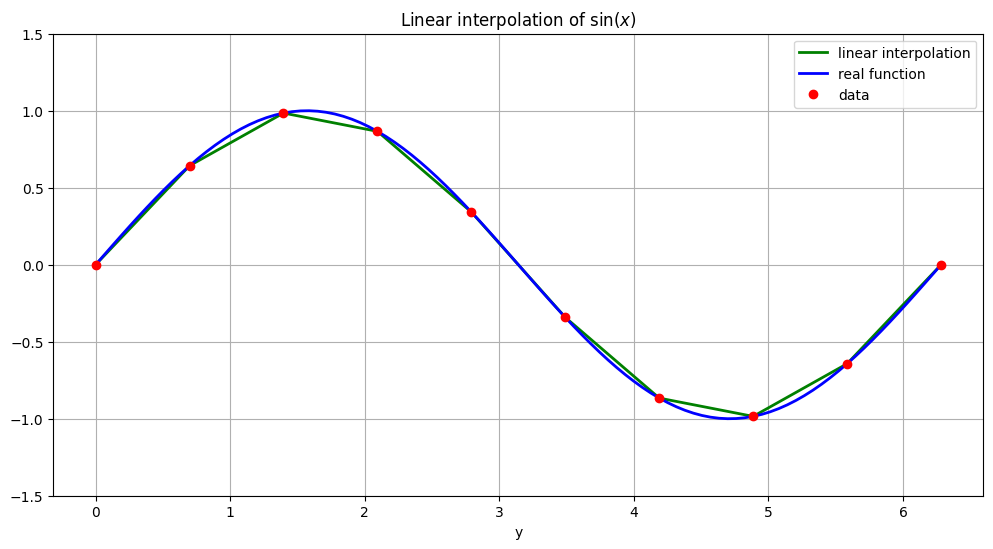

In [ ]:
def function(x):
    return np.sin(x)

#Number of intervals for data
Ndat = 10
Xn = np.linspace( 0, 2*np.pi, Ndat )
Yn = function(Xn)

#Obtaining linear interpolation
Ninter = 100
x = np.linspace( 0, 2*np.pi, Ninter)
y = LinearInterpolator( x, Xn, Yn )
f = function(x)

#Plotting
plt.figure( figsize=(12,6) )
plt.plot( x, y, color="green", linewidth=2, label="linear interpolation" )
plt.plot( x, f, color="blue", linewidth=2, label="real function" )
plt.plot( Xn, Yn, "o", color="red", label="data" )

#Formatting
plt.legend()
plt.grid()
plt.xlabel( "x" )
plt.xlabel( "y" )
plt.ylim( (-1.5,1.5) )
plt.title( "Linear interpolation of $\sin(x)$" )

## Interpolación de Lagrange

El problema de la interpolación polinómica de Lagrange consiste en lo siguiente:
Conocidos los valores de una función $f$ en $n + 1$ puntos distintos $x_i$ , $i =0, 1, · · · , n$ de un intervalo $[a, b]$, nos planteamos obtener un polinomio $P_n$ de grado no superior a $n$, que coincida con la función $f$ en estos $n + 1$ puntos, es decir, la **interpolación polinomial de Lagrange** encuentra un único polinomio que pasa por todos los puntos de datos.
$$P_n(x_i)=f(x_i)$$ para $$i=0,1,...,n$$

Este polinomio se conoce como **polinomio de Lagrange**, $ L (x) $, y como función de interpolación, debe tener la propiedad $ L (x_i) = y_i $ para cada punto del conjunto de datos. Para calcular polinomios de Lagrange, es útil escribirlos como una combinación lineal de **polinomios de base de Lagrange**, $ P_i (x) $, donde
$$
P_i(x) = \prod_{j = 1, j\ne i}^n\frac{x - x_j}{x_i - x_j},
$$

and
$$
L(x) = \sum_{i = 1}^n y_i P_i(x).
$$

Aquí, $ \prod $ significa "el producto de" o "multiplicar".

Notará que por construcción, $ P_i (x) $ tiene la propiedad de que $ P_i (x_i) = 1 $ cuando $ i = j $ y $ P_i (x_j) = 0 $ cuando $ i \ne j $. Como $ L (x) $ es una suma de estos polinomios, puede observar que $ L (x_i) = y_i $ para cada punto, exactamente como se desee.

### **Ejercicio 2:**
Encuentra los polinomios de base de Lagrange para el conjunto de datos *x = [0, 1, 2]* y *y = [1, 3, 2]*. Grafique cada polinomio y verifique la propiedad de que $ P_i (x_j) = 1 $ cuando $ i = j $ y $ P_i (x_j) = 0 $ cuando $ i \ne j $.




\begin{eqnarray*}
P_1(x) &=& \frac{(x - x_2)(x - x_3)}{(x_1-x_2)(x_1-x_3)} = \frac{(x - 1)(x - 2)}{(0-1)(0-2)} = \frac{1}{2}(x^2 - 3x + 2),\\
P_2(x) &=& \frac{(x - x_1)(x - x_3)}{(x_2-x_1)(x_2-x_3)} = \frac{(x - 0)(x - 2)}{(1-0)(1-2)} = -x^2 + 2x,\\
P_3(x) &=& \frac{(x - x_1)(x - x_2)}{(x_3-x_1)(x_3-x_2)} = \frac{(x - 0)(x - 1)}{(2-0)(2-1)} = \frac{1}{2}(x^2 - x).
\end{eqnarray*}

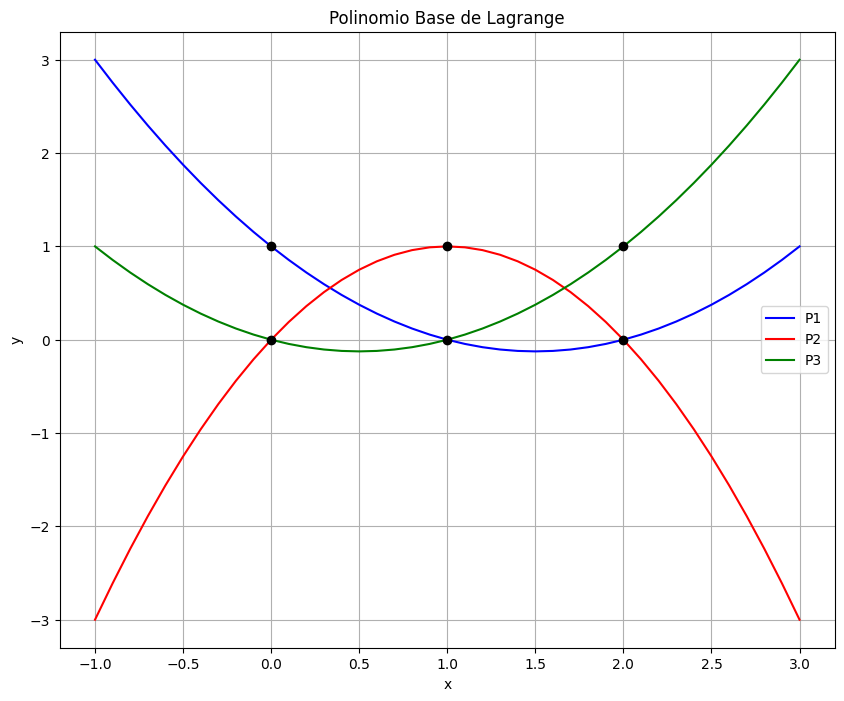

In [ ]:
import numpy as np
import numpy.polynomial.polynomial as poly
import matplotlib.pyplot as plt
x = [0, 1, 2]
y = [1, 3, 2]
P1_coeff = [1,-1.5,.5]
P2_coeff = [0, 2,-1]
P3_coeff = [0,-.5,.5]

# Construye el polinomio de gradi n-1
P1 = poly.Polynomial(P1_coeff)
P2 = poly.Polynomial(P2_coeff)
P3 = poly.Polynomial(P3_coeff)

x_new = np.arange(-1.0, 3.1, 0.1)

fig = plt.figure(figsize = (10,8))
plt.plot(x_new, P1(x_new), 'b', label = 'P1')
plt.plot(x_new, P2(x_new), 'r', label = 'P2')
plt.plot(x_new, P3(x_new), 'g', label = 'P3')

plt.plot(x, np.ones(len(x)), 'ko', x, np.zeros(len(x)), 'ko')
plt.title('Polinomio Base de Lagrange')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend()
plt.show()

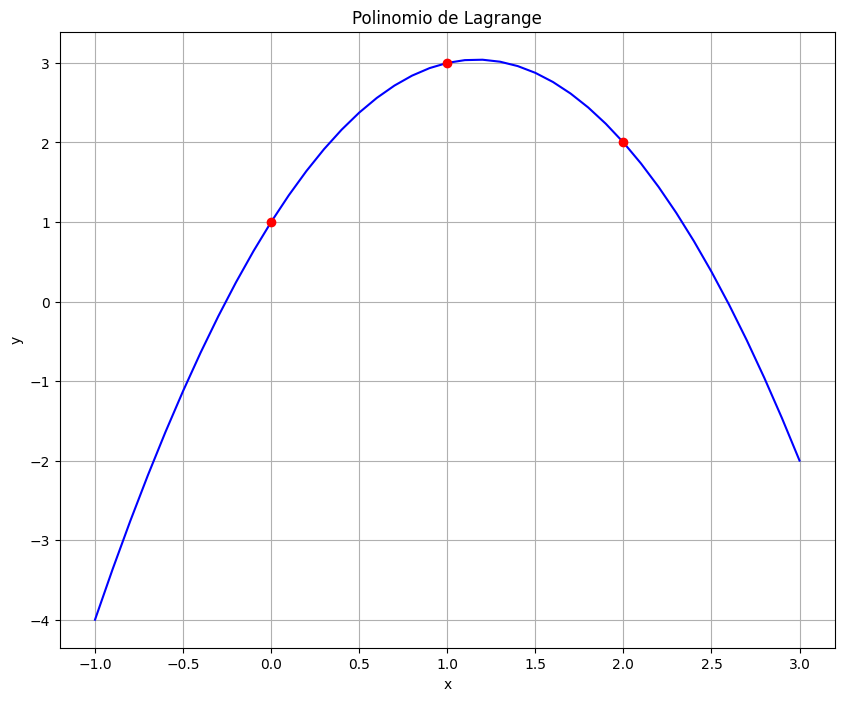

In [ ]:
L = 1*P1 + 3*P2 + 2*P3

fig = plt.figure(figsize = (10,8))
plt.plot(x_new, L(x_new), 'b', x, y, 'ro')
plt.title('Polinomio de Lagrange')
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### **Ejercicio 3**

Escriba los pasos a seguir para desarrollar el algoritmo de lagrange.

### Steps LP

Una vez definido el procedimiento formal para la construcción de un polinomio de Lagrange, procedemos a describir el algoritmo explícito:

1. Tome conjunto de datos de trabajo $ (x_i, y_i) $ y establezca cuántos puntos tiene.
2. Defina las funciones $P_ {n, i} (x) $ de forma general.
3. Agregue cada uno de esos términos como se muestra en la última expresión.
4. Evalúe su resultado donde quiera.

### **Tarea**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def P_n(xi,yi,x):
    '''
     *** P_n(x): polinomio de grado n evaluado en x ***
    Función del polinomio de lagrange (forma
    intuitiva de programación a partir de la definición).
    '''

    n = len(xi)          # grado del polinomio
    S = 0.0              # inicialización sumatoria
    for k in range(n):   # Sumatoria del polinomio en n+1 elementos
        # Forma intuitiva a partir de la fórmula
        L = 1
        for i in range(n):
            if i != k:
                L = L*(x-xi[i])/(xi[k]-xi[i])

        S  = S + yi[k]*L

    return S

In [ ]:
#-------------------- Interpolación de Lagrange --------------------------
def Interpolacion_Lagrange(xi,yi,eps):
   ''' Esta funcion toma n+1 pares (xi,yi) de datos y los interpola
       en intervalo (x0,xn) usando el metodo de lagrange.'''

   n = len(xi)-1 # el array tiene n+1 elementos.
   print ("El grado del Pn(x) es:",n)

   x = np.arange(xi[0],xi[n], eps)  # Valores a interpolar
   P = np.array([P_n(xi,yi,xk) for xk in x]) # Polinomio P(x) de grado n evaluado en x

   plt.plot(x,P,label="Lagrange")       # Graficar interpolación de lagrange.
   plt.legend()
   plt.show()

El grado del Pn(x) es: 2


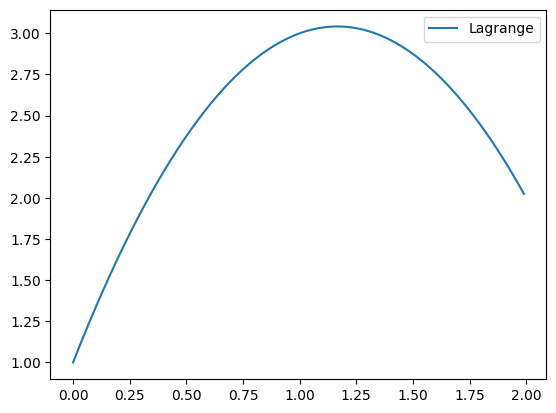

In [ ]:
x1 = [0, 1, 2]
y1 = [1, 3, 2]
Interpolacion_Lagrange(x1,y1,0.01)